In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from model_ldon_2d import *
from helper import *

In [2]:
train_path = "latent_deeponet_advdiff_train_36k.npz"
test_path  = "latent_deeponet_advdiff_test_12k.npz"

branch_tr, trunk_tr, y_tr, alpha_tr = load_latent_deeponet_advdiff_npz(train_path)
branch_te, trunk_te, y_te, alpha_te = load_latent_deeponet_advdiff_npz(test_path)

Loaded: latent_deeponet_advdiff_train_36k.npz
branch_inputs: (36000, 1, 128, 128) float32
trunk_inputs : (36000, 1) float32
targets      : (36000, 1, 128, 128) float32
alpha_values : (36000, 1) float32
Loaded: latent_deeponet_advdiff_test_12k.npz
branch_inputs: (12000, 1, 128, 128) float32
trunk_inputs : (12000, 1) float32
targets      : (12000, 1, 128, 128) float32
alpha_values : (12000, 1) float32


### Loading the AE and the trained weights

In [3]:
encoder = Encoder()
decoder = Decoder()
model = AE_2D_AdvDif(encoder, decoder)

# Loading the trained weights:
def load_best_weights(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()
    print(f"Loaded checkpoint: {ckpt_path}")
    print(f"  epoch: {ckpt.get('epoch', 'NA')}, best_val_loss: {ckpt.get('best_val_loss', 'NA')}")
    return model, ckpt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "best_ae_advdiff.pt"  # <- your saved best checkpoint
model, ckpt = load_best_weights(model, ckpt_path, device)

Loaded checkpoint: best_ae_advdiff.pt
  epoch: 94, best_val_loss: 3.7451536859407497e-06


In [4]:
# Hyperparams
m = 3       
p = 32
branch = BranchMLP(in_dim=m, m=m, p=p, hidden=(64, 128)).to(device)
trunk  = TrunkMLP(loc_dim=1, m=m, p=p, hidden=(128, 256)).to(device)

In [5]:
mu_z = torch.tensor([ 14.4788, 112.3113,  40.3706]).to(device)
std_z = torch.tensor([162.1621,  61.3577,  64.0876]).to(device)

In [6]:
# Loading the LDON weights -
l_donet_load_path = "./best_latent_deeponet_advdiff.pt"  # <-- update if your filename differs
ckpt = torch.load(l_donet_load_path, map_location=device)

# (Optional) sanity print
print(f"Loaded checkpoint from epoch {ckpt.get('epoch', 'N/A')} | best_val = {ckpt.get('best_val', 'N/A')}")

branch.load_state_dict(ckpt["branch"], strict=True)
trunk.load_state_dict(ckpt["trunk"], strict=True)

branch = branch.to(device).eval()
trunk  = trunk.to(device).eval()

Loaded checkpoint from epoch 69 | best_val = 0.014098387204421064


## Loading the D-LEO-VAE Model.

In [7]:
from data import *
from model_io import load_model, save_model
from d_leo_vae import Encoder, Decoder, Propagator_concat as Propagator, Model as D_LEO_VAE

In [8]:
model_path = "./D_LEO_VAE_Best.pt"

def get_model(latent_dim, device="cpu"):
    encoder = Encoder(latent_dim)
    decoder = Decoder(latent_dim)
    propagator = Propagator(latent_dim)
    model = D_LEO_VAE(encoder, decoder, propagator)
    return model.to(device)

# build model
D_LEO_VAE_Model = get_model(latent_dim=3, device=device)
# load checkpoint
ckpt = torch.load(model_path, map_location=device)

# handle common checkpoint formats
if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    # assume the file itself is a raw state_dict
    state_dict = ckpt

# (optional) strip "module." if trained with DataParallel
new_state_dict = {}
for k, v in state_dict.items():
    new_state_dict[k.replace("module.", "")] = v

# load weights
missing, unexpected = D_LEO_VAE_Model.load_state_dict(new_state_dict, strict=False)

print("Loaded weights.")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

D_LEO_VAE_Model.eval();

Loaded weights.
Missing keys: []
Unexpected keys: []


## Validation -

In [9]:
def forward_latent(x, t, mu_z, std_z):
    """
    x: [B,1,H,W]
    t: [B,1]
    returns: z_pred_norm [B,m]
    """
    with torch.no_grad():
        z0 = encoder(x)                      # [B,m]
        z0 = normalize_z(z0, mu_z, std_z)    # [B,m] normalized

    yb = branch(z0)          # [B,m,p]
    yt = trunk(t)            # [B,m,p]

    z_pred_norm = torch.einsum("bmp,bmp->bm", yb, yt)  # [B,m]
    return z_pred_norm

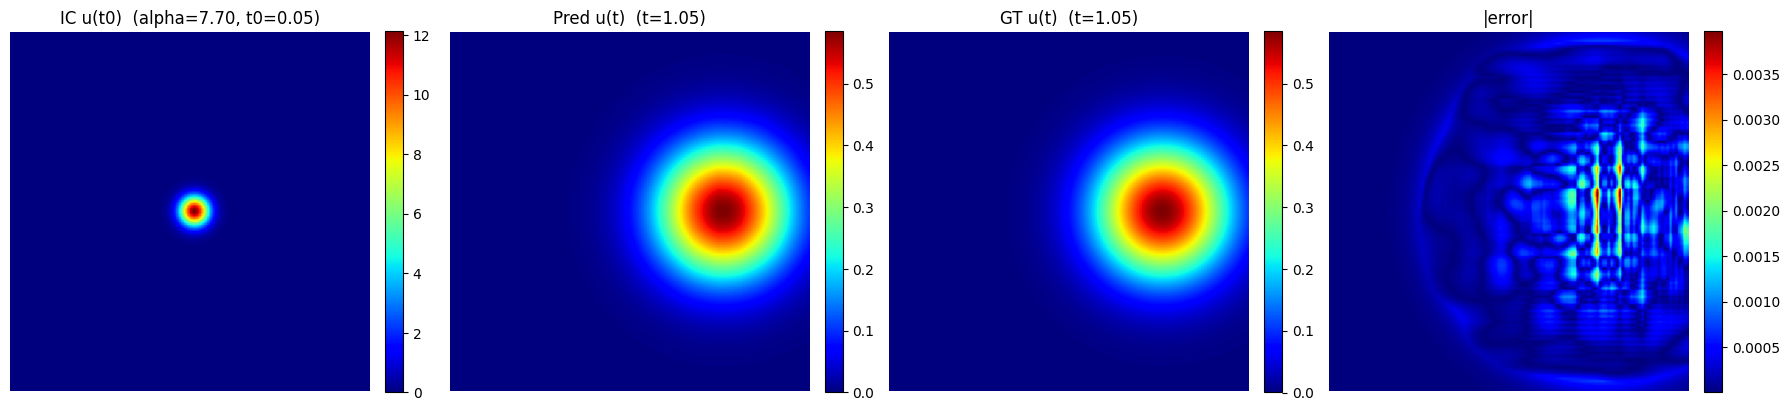

In [10]:
# Validation -
# IC -> Enc -> z(IC) --- { z(IC) -> Branch; t_query -> Trunk; fuse } -> z(t_query) -> Decode -> u_pred(t_query)

# Build time grid (you can change t0 whenever you want)
num_time_steps = 500
def get_dt(num_time_steps):
    return 2.0 / num_time_steps

t0, t_end = 0.05, 2.05          # <-- YOU control t0
dt = get_dt(num_time_steps)
t_range = np.arange(t0, t_end, dt)  # physical times


@torch.no_grad()
def validation(alpha_val, device, mu_z, std_z, t0=t0, t_end=t_end, t_range=t_range):
    """
    Input:
      alpha_val : float
      t0        : initial condition time (float)
    Output:
      u_pred(t_query), u_ic(t0), u_gt(t_query), t0, t_query
    """
    # pick a random query time index such that t_query > t0
    k = np.random.randint(1, len(t_range))
    t_query = float(t_range[k])

    if t_query >= t_end:
        print(f"Re-run: sampled t_query={t_query:.4f} >= t_end={t_end:.4f}")
        return None, None, None, None, None

    # IC at t0
    u_ic_np = exact_solution(alpha_val, t0)  # (H,W)
    u_ic = torch.tensor(u_ic_np, dtype=torch.float32, device=device)[None, None]  # [1,1,H,W]

    # query time (physical)
    t_query_tensor = torch.tensor(t_query, dtype=torch.float32, device=device)[None, None]  # [1,1]

    # predict normalized latent at t_query
    z_pred_norm = forward_latent(u_ic, t_query_tensor, mu_z, std_z)  # [1,m]

    # denormalize latent BEFORE decoding
    mu = mu_z.to(device).view(1, -1)
    sd = std_z.to(device).view(1, -1)
    z_pred = z_pred_norm * sd + mu                                    # [1,m]

    # decode
    u_pred = decoder(z_pred)  # [1,1,H,W]

    # ground truth
    u_gt = exact_solution(alpha_val, t_query)

    return (
        u_pred.detach().cpu().numpy().squeeze(),  # (H,W)
        u_ic.detach().cpu().numpy().squeeze(),    # (H,W)
        u_gt,                                     # (H,W)
        float(t0),
        t_query
    )

# Example usage
alpha_test = 7.7
u_pred, u_ic, u_gt, t0_used, t_query = validation(alpha_test, device, mu_z, std_z, t0=t0)

# Plot (1x4)
plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.title(f"IC u(t0)  (alpha={alpha_test:.2f}, t0={t0_used:.2f})")
plt.imshow(u_ic, cmap="jet", origin="lower")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title(f"Pred u(t)  (t={t_query:.2f})")
plt.imshow(u_pred, cmap="jet", origin="lower")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title(f"GT u(t)  (t={t_query:.2f})")
plt.imshow(u_gt, cmap="jet", origin="lower")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("|error|")
plt.imshow(np.abs(u_pred - u_gt), cmap="jet", origin="lower")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# # Build time grid (we can change t0 whenever you want)
# num_time_steps = 500
# def get_dt(num_time_steps):
#     return 2.0 / num_time_steps

# t0, t_end = 0.25, 2.05
# dt = get_dt(num_time_steps)
# t_range = np.arange(t0, t_end, dt)  # physical times


# @torch.no_grad()
# def compare_ldon_vs_dleo(alpha_val, device, mu_z, std_z,
#                          D_LEO_VAE_Model,
#                          t0=t0, t_end=t_end, t_range=t_range, dt=dt):
#     """
#     Returns:
#       u_ic, u_gt, t0_used, t_query
#       u_pred_ldon, err_ldon
#       u_pred_dleo, err_dleo
#     """

#     # pick a random query time index such that t_query > t0
#     k = np.random.randint(1, len(t_range))
#     t_query = float(t_range[k])

#     if t_query >= t_end:
#         print(f"Re-run: sampled t_query={t_query:.4f} >= t_end={t_end:.4f}")
#         return None

#     # IC field at t0
#     u_ic_np = exact_solution(alpha_val, t0)  # (H,W)
#     u_ic = torch.tensor(u_ic_np, dtype=torch.float32, device=device)[None, None]  # [1,1,H,W]
#     # Ground truth at query
#     u_gt = exact_solution(alpha_val, t_query)  # (H,W)

#     # Latent DeepONet pred
#     t_query_tensor = torch.tensor(t_query, dtype=torch.float32, device=device)[None, None]  # [1,1]
#     z_pred_norm = forward_latent(u_ic, t_query_tensor, mu_z, std_z)  # [1,m]  (normalized latent)
#     mu = mu_z.to(device).view(1, -1)
#     sd = std_z.to(device).view(1, -1)
#     z_pred = z_pred_norm * sd + mu  # denormalize to encoder-latent scale
#     u_pred_ldon = decoder(z_pred)  # [1,1,H,W]
#     u_pred_ldon_np = u_pred_ldon.detach().cpu().numpy().squeeze()
#     err_ldon = np.abs(u_pred_ldon_np - u_gt)

#     # D-LEO-VAE pred
#     # tau in steps
#     tau_steps = int(np.round((t_query - t0) / dt))
#     tau_steps = max(tau_steps, 0)

#     # model expects tensors for tau and alpha
#     # tau: [1,1] float or long (your propagator likely treats it as conditioning input)
#     tau_tensor = torch.tensor([[tau_steps]], dtype=torch.float32, device=device)  # [1,1]
#     alpha_tensor = torch.tensor([[alpha_val]], dtype=torch.float32, device=device)  # [1,1]

#     D_LEO_VAE_Model.eval()
#     out = D_LEO_VAE_Model(u_ic, tau_tensor, alpha_tensor)
#     # support both return styles:
#     # either (x_hat, x_hat_tau, mean, log_var, z_tau)
#     # or dict-like
#     if isinstance(out, (tuple, list)) and len(out) >= 2:
#         x_hat_tau = out[1]
#     elif isinstance(out, dict) and "x_hat_tau" in out:
#         x_hat_tau = out["x_hat_tau"]
#     else:
#         raise ValueError("Unexpected D_LEO_VAE_Model output format. Print(out) once to confirm.")

#     u_pred_dleo_np = x_hat_tau.detach().cpu().numpy().squeeze()
#     err_dleo = np.abs(u_pred_dleo_np - u_gt)

#     return {
#         "u_ic": u_ic.detach().cpu().numpy().squeeze(),
#         "u_gt": u_gt,
#         "t0": float(t0),
#         "t_query": t_query,
#         "tau_steps": tau_steps,
#         "u_pred_ldon": u_pred_ldon_np,
#         "err_ldon": err_ldon,
#         "u_pred_dleo": u_pred_dleo_np,
#         "err_dleo": err_dleo,
#     }


# # Example usage + plot
# alpha_test = 1.4
# res = compare_ldon_vs_dleo(alpha_test, device, mu_z, std_z, D_LEO_VAE_Model, t0=t0)

# u_ic   = res["u_ic"]
# u_gt   = res["u_gt"]
# t0_used = res["t0"]
# t_query = res["t_query"]
# tau_steps = res["tau_steps"]

# u_pred_ldon = res["u_pred_ldon"]
# err_ldon    = res["err_ldon"]

# u_pred_dleo = res["u_pred_dleo"]
# err_dleo    = res["err_dleo"]

# plt.figure(figsize=(18, 8))

# # Row 1: L-DeepONet
# plt.subplot(2, 4, 1)
# plt.title(f"IC u(t0)\nalpha={alpha_test:.2f}, t0={t0_used:.2f}")
# plt.imshow(u_ic, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# plt.subplot(2, 4, 2)
# plt.title(f"L-DeepONet pred\n t={t_query:.2f}")
# plt.imshow(u_pred_ldon, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# plt.subplot(2, 4, 3)
# plt.title(f"GT\n t={t_query:.2f}")
# plt.imshow(u_gt, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# plt.subplot(2, 4, 4)
# plt.title("|err| (L-DeepONet)")
# plt.imshow(err_ldon, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# # Row 2: D-LEO-VAE
# plt.subplot(2, 4, 5)
# plt.title(f"IC u(t0)\n(same)")
# plt.imshow(u_ic, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# plt.subplot(2, 4, 6)
# plt.title(f"D-LEO-VAE pred\n tau={tau_steps} steps")
# plt.imshow(u_pred_dleo, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# plt.subplot(2, 4, 7)
# plt.title(f"GT\n t={t_query:.2f}")
# plt.imshow(u_gt, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# plt.subplot(2, 4, 8)
# plt.title("|err| (D-LEO-VAE)")
# plt.imshow(err_dleo, cmap="jet", origin="lower"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis("off")

# plt.tight_layout()
# plt.show()

## Metrics

[WARN] zone=Left extrapolation t0=1.4500: L-DON collected 0/1000 (attempts=50000)
[WARN] zone=Left extrapolation t0=1.4500: D-LEO collected 0/1000 (attempts=50000)
[WARN] zone=Interpolation t0=1.4500: L-DON collected 0/1000 (attempts=50000)
[WARN] zone=Interpolation t0=1.4500: D-LEO collected 0/1000 (attempts=50000)
[WARN] zone=Right extrapolation t0=1.4500: L-DON collected 0/1000 (attempts=50000)
[WARN] zone=Right extrapolation t0=1.4500: D-LEO collected 0/1000 (attempts=50000)


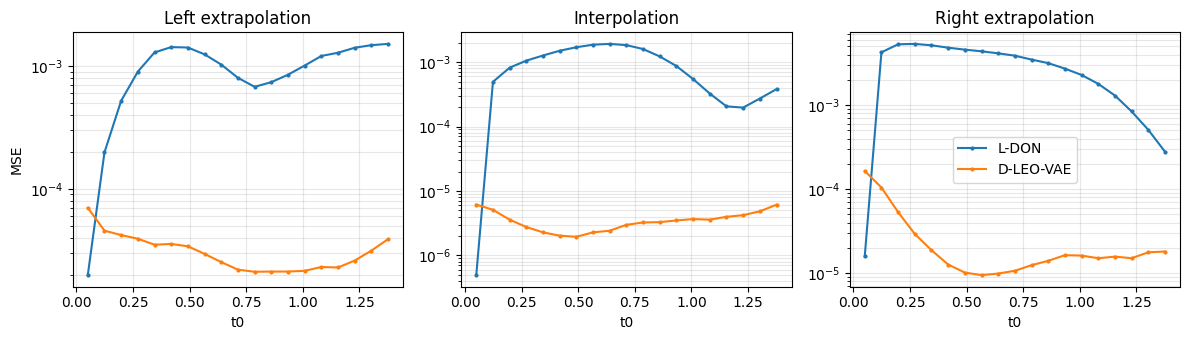


=== Zone-aggregated MSE over all sampled (t0, alpha, tau) ===

Left extrapolation
  L-DON     : 9.980e-04 ± 6.709e-04   (N=19000)
  D-LEO-VAE : 3.188e-05 ± 3.732e-05   (N=19000)

Interpolation
  L-DON     : 9.519e-04 ± 6.588e-04   (N=19000)
  D-LEO-VAE : 3.562e-06 ± 4.564e-06   (N=19000)

Right extrapolation
  L-DON     : 3.066e-03 ± 2.048e-03   (N=19000)
  D-LEO-VAE : 2.972e-05 ± 1.438e-04   (N=19000)


In [12]:
sampling = 0.05
alpha_min, alpha_max = 1.0, 10.0

a_left_max   = 1.9
a_train1_max = 2.09
a_interp_max = 2.99
a_train2_max = 9.1

alpha_left_extrp  = np.arange(alpha_min, a_left_max, sampling)
alpha_train_1     = np.arange(a_left_max, a_train1_max, sampling)
alpha_interp      = np.arange(a_train1_max, a_interp_max, sampling)
alpha_train_2     = np.arange(a_interp_max, a_train2_max, sampling)
alpha_right_extrp = np.arange(a_train2_max, alpha_max + 1e-12, sampling)

# Helpers
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def sample_tau_steps_banded(t0, dt, t_end, tau_min=150, tau_max=425, strict=True):
    """
    Sample integer tau_steps in [tau_min, tau_max] such that:
        strict=True  -> t0 + tau*dt <  t_end
        strict=False -> t0 + tau*dt <= t_end
    Returns None if no feasible tau exists for this t0.
    """
    if strict:
        max_steps_time = int(np.floor((t_end - t0) / dt)) - 1
    else:
        max_steps_time = int(np.floor((t_end - t0) / dt))

    lo = int(tau_min)
    hi = min(int(tau_max), max_steps_time)

    if hi < lo:
        return None

    return np.random.randint(lo, hi + 1)

# Model predictors
@torch.no_grad()
def predict_ldon(alpha, t0, tau_steps, device, mu_z, std_z, dt, t_end):
    """
    Latent DeepONet prediction:
      IC at time t0
      query at t_query = t0 + tau_steps * dt
      trunk takes physical time (t_query)
    """
    t_query = float(t0 + tau_steps * dt)
    if t_query >= t_end:
        return None, None

    u0_np = exact_solution(alpha, t0)  # (H,W)
    u0 = torch.tensor(u0_np, dtype=torch.float32, device=device)[None, None]  # [1,1,H,W]

    t_tensor = torch.tensor(t_query, dtype=torch.float32, device=device)[None, None]  # [1,1]

    # forward_latent returns normalized latent
    z_pred_norm = forward_latent(u0, t_tensor, mu_z, std_z)  # [1,m]

    # denormalize BEFORE decoding
    mu = mu_z.to(device).view(1, -1)
    sd = std_z.to(device).view(1, -1)
    z_pred = z_pred_norm * sd + mu

    u_pred = decoder(z_pred)  # [1,1,H,W]
    return u_pred[0, 0].detach().cpu().numpy(), t_query


@torch.no_grad()
def predict_dleo(alpha, t0, tau_steps, device, dt, t_end, use_tau_physical=False):
    """
    D-LEO-VAE prediction:
      input: (u0, tau, alpha)
      output: x_hat_tau assumed to be out[1] if tuple/list (x_hat, x_hat_tau, ...)
    """
    t_query = float(t0 + tau_steps * dt)
    if t_query >= t_end:
        return None, None

    u0_np = exact_solution(alpha, t0)
    u0 = torch.tensor(u0_np, dtype=torch.float32, device=device)[None, None]  # [1,1,H,W]

    if use_tau_physical:
        tau_in = torch.tensor([tau_steps * dt], dtype=torch.float32, device=device).view(1, 1)
    else:
        tau_in = torch.tensor([tau_steps], dtype=torch.float32, device=device).view(1, 1)

    alpha_in = torch.tensor([alpha], dtype=torch.float32, device=device).view(1, 1)

    out = D_LEO_VAE_Model(u0, tau_in, alpha_in)

    if isinstance(out, (tuple, list)) and len(out) >= 2:
        x_hat_tau = out[1]
    else:
        x_hat_tau = out

    return x_hat_tau[0, 0].detach().cpu().numpy(), t_query


# Core metric sweep 
@torch.no_grad()
def compute_mse_vs_t0(
    t0_list,
    zones,
    n_samples_per_t0=500,
    device="cuda",
    mu_z=None,
    std_z=None,
    dt=0.004,
    t_end=2.05,
    tau_min=150,
    tau_max=425,
    use_tau_physical_for_dleo=False,
    strict_tend=True,
    max_attempts_factor=50,
    verbose=True,
):
    """
    - For each zone and each t0: tries to collect EXACTLY n_samples_per_t0 samples (per model).
    - Also aggregates ALL collected sample errors across ALL t0 for that zone -> zone mean±std.
    """
    if mu_z is None or std_z is None:
        raise ValueError("mu_z and std_z must be provided for L-DON normalization/denormalization.")

    results = {}

    for zone_name, alpha_pool in zones.items():
        alpha_pool = np.array(alpha_pool).astype(np.float32)

        ldon_means, ldon_stds = [], []
        dleo_means, dleo_stds = [], []

        # >>> collect ALL errors across all t0 (zone-level stats)
        all_ldon_errs_zone = []
        all_dleo_errs_zone = []

        for t0 in t0_list:
            t0 = float(t0)

            ldon_errs = []
            dleo_errs = []

            max_attempts = int(max_attempts_factor * n_samples_per_t0)
            attempts = 0

            # collect until we have n_samples_per_t0 for both (independently)
            while (len(ldon_errs) < n_samples_per_t0 or len(dleo_errs) < n_samples_per_t0) and attempts < max_attempts:
                attempts += 1

                alpha = float(np.random.choice(alpha_pool))
                tau_steps = sample_tau_steps_banded(
                    t0=t0, dt=dt, t_end=t_end,
                    tau_min=tau_min, tau_max=tau_max,
                    strict=strict_tend
                )
                if tau_steps is None:
                    continue

                t_query = float(t0 + tau_steps * dt)
                if t_query >= t_end:
                    continue

                u_gt = exact_solution(alpha, t_query)

                # L-DON
                if len(ldon_errs) < n_samples_per_t0:
                    u_pred_ldon, _ = predict_ldon(alpha, t0, tau_steps, device, mu_z, std_z, dt, t_end)
                    if u_pred_ldon is not None:
                        e = mse(u_pred_ldon, u_gt)
                        ldon_errs.append(e)
                        all_ldon_errs_zone.append(e)

                # D-LEO
                if len(dleo_errs) < n_samples_per_t0:
                    u_pred_dleo, _ = predict_dleo(alpha, t0, tau_steps, device, dt, t_end,
                                                  use_tau_physical=use_tau_physical_for_dleo)
                    if u_pred_dleo is not None:
                        e = mse(u_pred_dleo, u_gt)
                        dleo_errs.append(e)
                        all_dleo_errs_zone.append(e)

            # per-t0 stats
            if len(ldon_errs) < n_samples_per_t0:
                if verbose:
                    print(f"[WARN] zone={zone_name} t0={t0:.4f}: L-DON collected {len(ldon_errs)}/{n_samples_per_t0} (attempts={attempts})")
                ldon_means.append(np.nan); ldon_stds.append(np.nan)
            else:
                arr = np.asarray(ldon_errs, dtype=np.float64)
                ldon_means.append(arr.mean()); ldon_stds.append(arr.std())

            if len(dleo_errs) < n_samples_per_t0:
                if verbose:
                    print(f"[WARN] zone={zone_name} t0={t0:.4f}: D-LEO collected {len(dleo_errs)}/{n_samples_per_t0} (attempts={attempts})")
                dleo_means.append(np.nan); dleo_stds.append(np.nan)
            else:
                arr = np.asarray(dleo_errs, dtype=np.float64)
                dleo_means.append(arr.mean()); dleo_stds.append(arr.std())

        # zone-level stats across ALL samples over ALL t0
        results[zone_name] = {
            "ldon_mean": np.array(ldon_means, dtype=np.float64),
            "ldon_std":  np.array(ldon_stds, dtype=np.float64),
            "dleo_mean": np.array(dleo_means, dtype=np.float64),
            "dleo_std":  np.array(dleo_stds, dtype=np.float64),

            "ldon_all_mean": float(np.mean(all_ldon_errs_zone)) if len(all_ldon_errs_zone) else np.nan,
            "ldon_all_std":  float(np.std(all_ldon_errs_zone))  if len(all_ldon_errs_zone) else np.nan,
            "dleo_all_mean": float(np.mean(all_dleo_errs_zone)) if len(all_dleo_errs_zone) else np.nan,
            "dleo_all_std":  float(np.std(all_dleo_errs_zone))  if len(all_dleo_errs_zone) else np.nan,

            "n_ldon_all": int(len(all_ldon_errs_zone)),
            "n_dleo_all": int(len(all_dleo_errs_zone)),
        }

    return results


# Plot (optionally add per-t0 ±std bands)
def plot_mse_vs_t0(t0_list, results, show_bands=True):
    zone_names = list(results.keys())
    plt.figure(figsize=(12, 3.5))

    for i, zone in enumerate(zone_names, 1):
        plt.subplot(1, len(zone_names), i)

        ldon_mu = results[zone]["ldon_mean"]
        ldon_sd = results[zone]["ldon_std"]
        dleo_mu = results[zone]["dleo_mean"]
        dleo_sd = results[zone]["dleo_std"]

        plt.plot(t0_list, ldon_mu, marker="o", markersize=2, label="L-DON")
        plt.plot(t0_list, dleo_mu, marker="o", markersize=2, label="D-LEO-VAE")

        if show_bands:
            # bands only where not nan
            t0 = np.asarray(t0_list)

            ok = np.isfinite(ldon_mu) & np.isfinite(ldon_sd)
            if np.any(ok):
                plt.fill_between(t0[ok], (ldon_mu-ldon_sd)[ok], (ldon_mu+ldon_sd)[ok], alpha=0.15)

            ok = np.isfinite(dleo_mu) & np.isfinite(dleo_sd)
            if np.any(ok):
                plt.fill_between(t0[ok], (dleo_mu-dleo_sd)[ok], (dleo_mu+dleo_sd)[ok], alpha=0.15)

        plt.yscale("log")
        plt.xlabel("t0")
        if i == 1:
            plt.ylabel("MSE")
        plt.title(zone)
        plt.grid(True, which="both", alpha=0.3)
        if i == len(zone_names):
            plt.legend()

    plt.tight_layout()
    plt.show()

def summarize_results_table(results):
    print("\n=== Zone-aggregated MSE over all sampled (t0, alpha, tau) ===")
    for zone, d in results.items():
        print(f"\n{zone}")
        print(f"  L-DON     : {d['ldon_all_mean']:.3e} ± {d['ldon_all_std']:.3e}   (N={d['n_ldon_all']})")
        print(f"  D-LEO-VAE : {d['dleo_all_mean']:.3e} ± {d['dleo_all_std']:.3e}   (N={d['n_dleo_all']})")


# Run
zones = {
    "Left extrapolation":  alpha_left_extrp,
    "Interpolation":       alpha_interp,
    "Right extrapolation": alpha_right_extrp,
}

# choose t0 sweep up to the max feasible t0 where tau_min still fits:
# t0 + tau_min*dt < t_end  ->  t0 < t_end - tau_min*dt
t0_min = 0.05
t0_max = (2.05 - 150 * dt) - 1e-6  # epsilon for strict <
t0_list = np.linspace(t0_min, t0_max, 20).astype(np.float32)

results = compute_mse_vs_t0(
    t0_list=t0_list,
    zones=zones,
    n_samples_per_t0=1000,
    device=device,
    mu_z=mu_z,
    std_z=std_z,
    dt=dt,
    t_end=2.05,
    tau_min=150,
    tau_max=425,
    use_tau_physical_for_dleo=False,  # True only if DLEO trained on tau_time
    strict_tend=True,                 # enforces t0 + tau*dt < 2.05
    verbose=True,
)

plot_mse_vs_t0(t0_list, results, show_bands=False)
summarize_results_table(results)

In [13]:
# def plot_mse_vs_t0(
#     t0_list,
#     results,
#     show_bands=True,
#     save_path=None,      # e.g. "mse_vs_t0.png" or "mse_vs_t0.pdf"
#     dpi=300,
# ):
#     zone_names = list(results.keys())
#     fig = plt.figure(figsize=(12, 3.5))

#     for i, zone in enumerate(zone_names, 1):
#         ax = fig.add_subplot(1, len(zone_names), i)

#         ldon_mu = results[zone]["ldon_mean"]
#         ldon_sd = results[zone]["ldon_std"]
#         dleo_mu = results[zone]["dleo_mean"]
#         dleo_sd = results[zone]["dleo_std"]

#         ax.plot(t0_list, ldon_mu, marker="o", markersize=2, label="L-DON")
#         ax.plot(t0_list, dleo_mu, marker="o", markersize=2, label="D-LEO-VAE")

#         if show_bands:
#             t0 = np.asarray(t0_list)

#             ok = np.isfinite(ldon_mu) & np.isfinite(ldon_sd)
#             if np.any(ok):
#                 ax.fill_between(t0[ok], (ldon_mu-ldon_sd)[ok], (ldon_mu+ldon_sd)[ok], alpha=0.15)

#             ok = np.isfinite(dleo_mu) & np.isfinite(dleo_sd)
#             if np.any(ok):
#                 ax.fill_between(t0[ok], (dleo_mu-dleo_sd)[ok], (dleo_mu+dleo_sd)[ok], alpha=0.15)

#         ax.set_yscale("log")
#         ax.set_xlabel("t0")
#         if i == 1:
#             ax.set_ylabel("MSE")
#         ax.set_title(zone)
#         ax.grid(True, which="both", alpha=0.3)
#         if i == len(zone_names):
#             ax.legend(fontsize=14, markerscale=2, handlelength=2)

#     fig.tight_layout()

#     if save_path is not None:
#         fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

#     plt.show()
#     return fig

In [14]:
# fig = plot_mse_vs_t0(
#     t0_list,
#     results,
#     show_bands=False,
#     save_path="mse_vs_t0_alpha_zones.png",
#     dpi=300,
# )

In [17]:
def count_parameters(model):
    """Count total trainable parameters in a model"""
    if model is None or not hasattr(model, "parameters"):
        return 0
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_simple_parameter_summary_advdiff(
    encoder=None,
    decoder=None,
    branch=None,
    trunk=None,
    d_leo_vae_model=None,
    label_ldon="L-DON",
    label_dleo="D-LEO-VAE",
):
    print("=" * 60)
    print("MODEL PARAMETER SUMMARY (trainable params)")
    print("=" * 60)

    # ---- L-DON ----
    ldon_params = 0
    ldon_components = [
        ("Encoder", encoder),
        ("Decoder", decoder),
        ("Branch",  branch),
        ("Trunk",   trunk),
    ]

    print(f"\n{label_ldon} Components:")
    for name, model in ldon_components:
        params = count_parameters(model)
        ldon_params += params
        if model is None:
            print(f"  {name:12}: {'(not provided)':>12}")
        else:
            print(f"  {name:12}: {params:>12,}")

    print(f"  {'Forward':12}: {'0':>12}  (function)")
    print(f"  {'TOTAL':12}: {ldon_params:>12,}")

    # ---- D-LEO-VAE ----
    print(f"\n{label_dleo}:")
    dleo_params = count_parameters(d_leo_vae_model)
    if d_leo_vae_model is None:
        print("  Model not found / None")
    else:
        print(f"  {'TOTAL':12}: {dleo_params:>12,}")

    # ---- Comparison ----
    if ldon_params > 0 and dleo_params > 0:
        print("\nComparison:")
        print(f"  {label_ldon:12}: {ldon_params:>12,}")
        print(f"  {label_dleo:12}: {dleo_params:>12,}")
        print(f"  Ratio ({label_dleo}/{label_ldon}): {dleo_params/ldon_params:.2f}x")

    return {"ldon": ldon_params, "dleo": dleo_params}

In [18]:
summary = print_simple_parameter_summary_advdiff(
    encoder=encoder,          # if you have it
    decoder=decoder,          # you DO have this (used in predict_ldon)
    branch=branch,            # if you have it
    trunk=trunk,              # if you have it
    d_leo_vae_model=D_LEO_VAE_Model,  # this is what your predict_dleo calls
)


MODEL PARAMETER SUMMARY (trainable params)

L-DON Components:
  Encoder     :      724,003
  Decoder     :      208,321
  Branch      :       20,960
  Trunk       :       57,952
  Forward     :            0  (function)
  TOTAL       :    1,011,236

D-LEO-VAE:
  TOTAL       :      962,314

Comparison:
  L-DON       :    1,011,236
  D-LEO-VAE   :      962,314
  Ratio (D-LEO-VAE/L-DON): 0.95x
